# NORMALIZATION AND SPLITTING

In [1]:
from src.dataset import load_dataset, get_random_sample, RadioMLConfig, normalize_rms, LoRaConfig
from src.utils import *

2026-04-29 15:15:13.679155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 15:15:13.690183: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-29 15:15:13.702821: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-29 15:15:13.706430: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-29 15:15:13.716784: I tensorflow/core/platform/cpu_feature_guar

**URL dataset:** https://www.kaggle.com/datasets/pinxau1000/radioml2018

# Load dataset and get config

In [3]:
path = "/home/wicom/Descargas/"
file = "RadioML2018_plus_LoRa.h5"
X, Y, Z = load_dataset(path, file)
classes = RadioMLConfig.CLASSES + LoRaConfig.CLASSES
fs = None

[INFO] Loading /home/wicom/Descargas/RadioML2018_plus_LoRa.h5 ...
[INFO] Loaded Dataset | X:(3194880, 1024, 2) Y:(3194880, 30) Z:(3194880, 1) | dtype X:float32


[INFO] Selected sample index: 2837978
[INFO] Label: 26 (LoRa-SF09) | SNR: 12.0 dB
[INFO] Average power: 0.001617


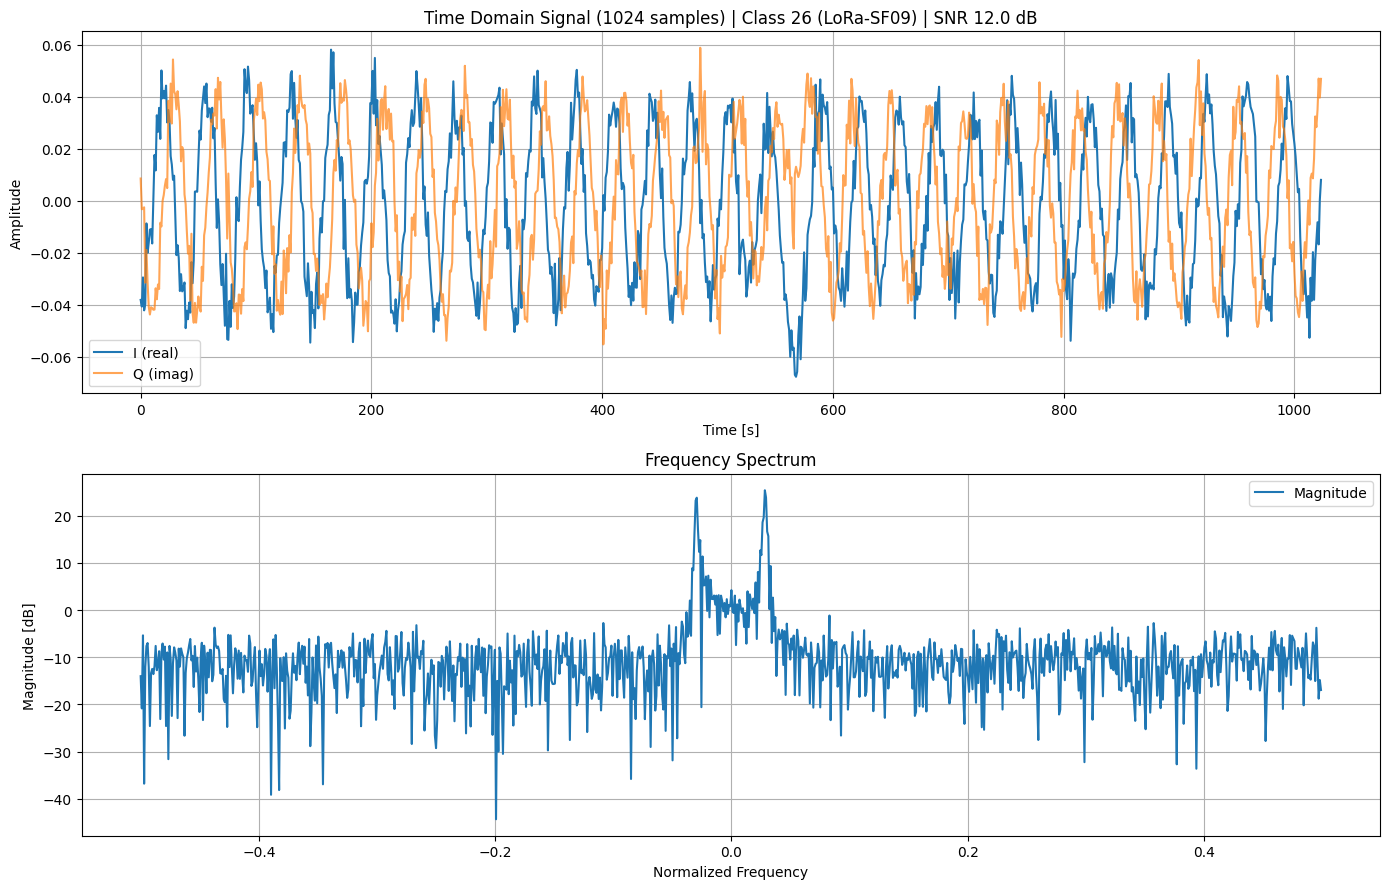

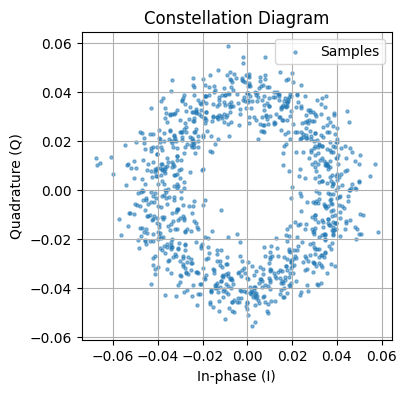

In [20]:
sample = get_random_sample(X, Y, np.squeeze(Z))
analyze_random_sample(sample, classes, plot_signal_analysis, fs=fs)

## Summary of combined dataset (Dtype and Size)

In [10]:
print("="*40)
print("Dataset combined")
print("="*40)
print(f"X.shape {X.shape} , X.dtype = {X.dtype}")
print(f"Y.shape {Y.shape} , Y.dtype = {Y.dtype}")
print(f"Z.shape {Z.shape} , Z.dtype = {Z.dtype}")

Dataset combined
X.shape (3194880, 1024, 2) , X.dtype = float32
Y.shape (3194880, 30) , Y.dtype = float32
Z.shape (3194880, 1) , Z.dtype = int8


Considerations:
* Data is not normalized, we might be under the risk that the model learns amplitude as a feature of the signal.
* We will deal with this situation by normalizing each 'frame' by their mean power

## Normalization (example)

In [11]:
X_norm = normalize_rms(X, eps=1e-10)

[INFO] Selected sample index: 2738937
[INFO] Label: 25 (LoRa-SF08) | SNR: 16.0 dB
[INFO] Average power: 1.000000


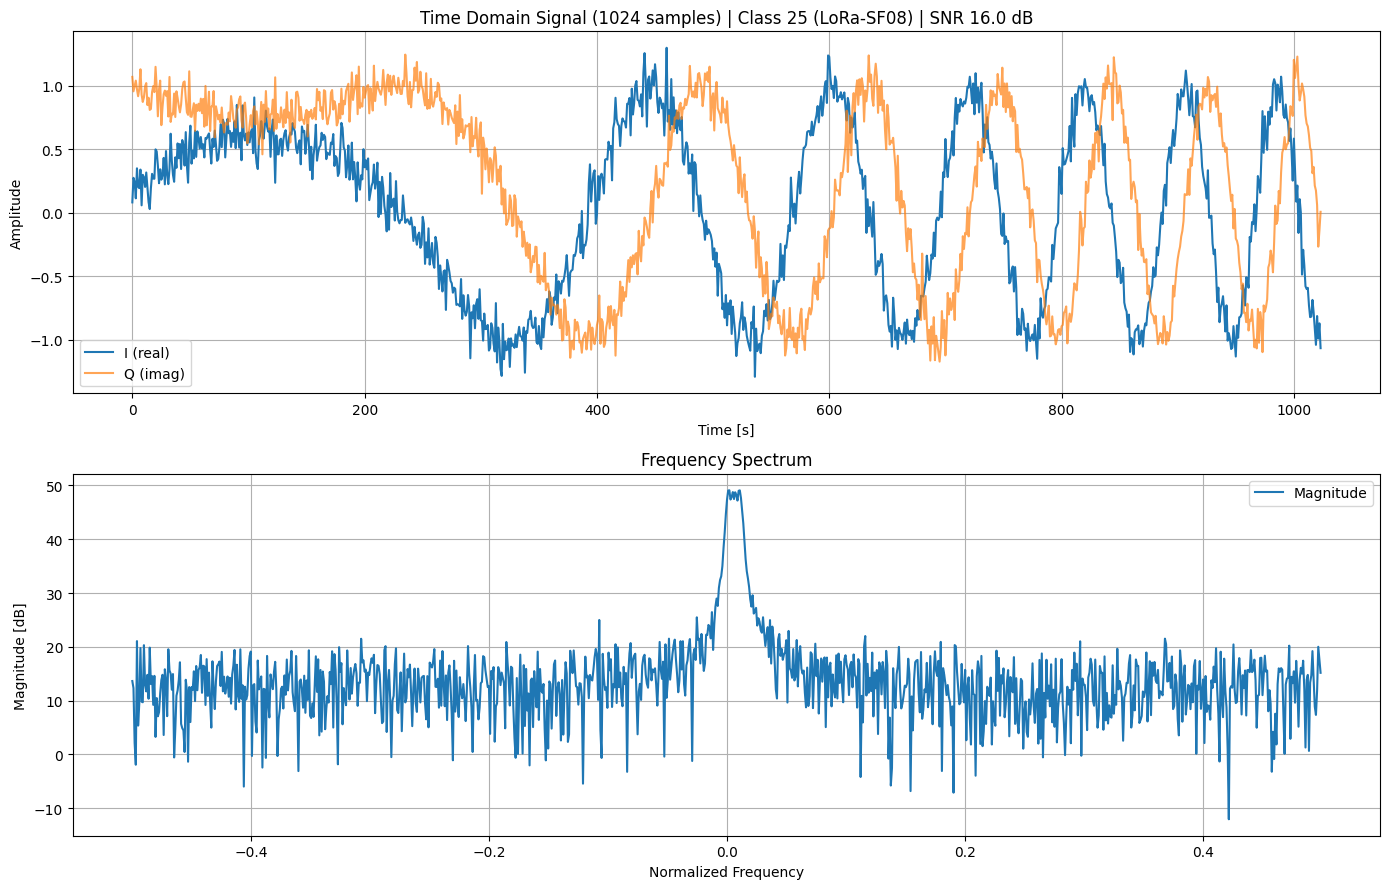

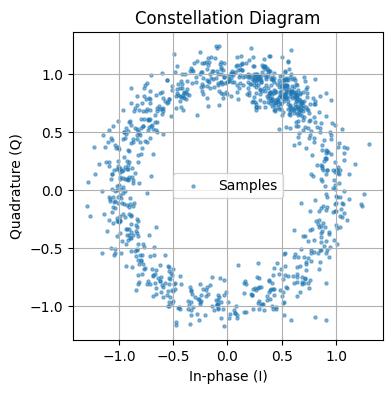

In [28]:
sample_norm = get_random_sample(X_norm, Y, Z)
analyze_random_sample(sample_norm, classes, plot_signal_analysis, fs=fs)

# Distribution analysis

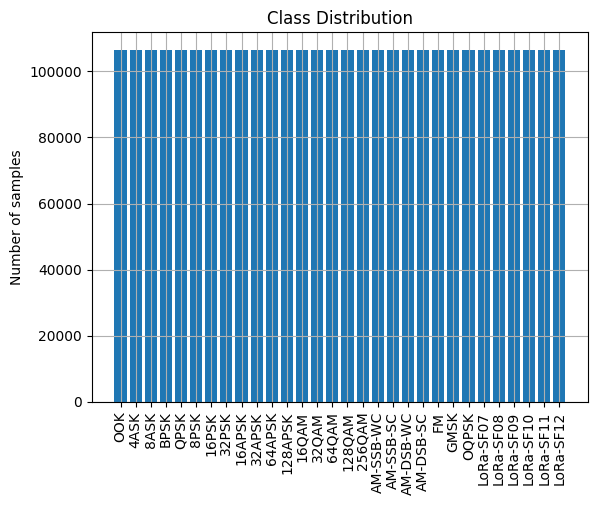

In [30]:
plot_class_distribution(Y=Y, class_names=classes)

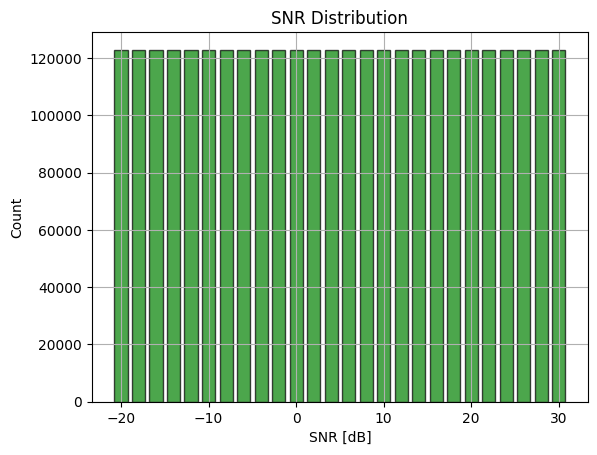

In [31]:
plot_snr_distribution(Z=Z)

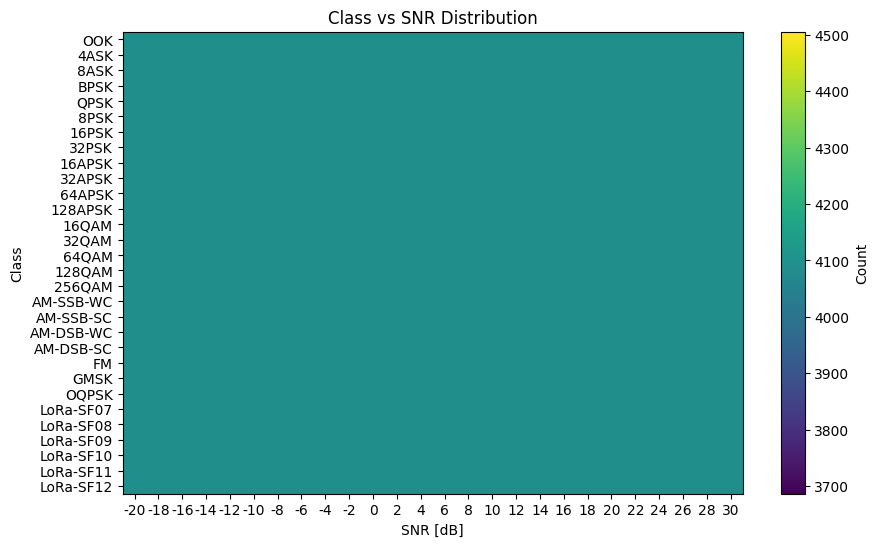

In [33]:
plot_class_snr_heatmap(Y=Y, Z=Z, class_names=classes)

## SPLIT THE DATASET

In [37]:
from sklearn.model_selection import train_test_split

In [74]:
import numpy as np
from sklearn.model_selection import train_test_split

def split_dataset(X, Y, Z, val_size=0.15, test_size=0.15, random_state=2980):

    class_labels = np.argmax(Y, axis=1)
    snr_labels = np.squeeze(Z)

    strat_labels = [
        f"{cls}_{snr}"
        for cls, snr in zip(class_labels, snr_labels)
    ]

    temp_size = val_size + test_size

    X_train, X_temp, Y_train, Y_temp, Z_train, Z_temp = train_test_split(
        X,
        Y,
        Z,
        test_size=temp_size,
        random_state=random_state,
        stratify=strat_labels
    )

    relative_test_size = test_size / temp_size

    temp_class_labels = np.argmax(Y_temp, axis=1)
    temp_snr_labels = np.squeeze(Z_temp)

    strat_temp = [
        f"{cls}_{snr}"
        for cls, snr in zip(temp_class_labels, temp_snr_labels)
    ]

    X_val, X_test, Y_val, Y_test, Z_val, Z_test = train_test_split(
        X_temp,
        Y_temp,
        Z_temp,
        test_size=relative_test_size,
        random_state=random_state,
        stratify=strat_temp
    )

    return (
        X_train, Y_train, Z_train,
        X_val, Y_val, Z_val,
        X_test, Y_test, Z_test
    )

We split the dataset:
* 80% for training
* 10% for validation
* 10% for test

In [62]:
X_train, Y_train, Z_train, X_val, Y_val, Z_val, X_test, Y_test, Z_test = split_dataset(X_norm, Y, Z, 
                                                                          val_size=0.10, 
                                                                            test_size=0.10, 
                                                                            random_state=2980)

In [63]:
X_train.shape, Y_train.shape, Z_train.shape

((2555904, 1024, 2), (2555904, 30), (2555904, 1))

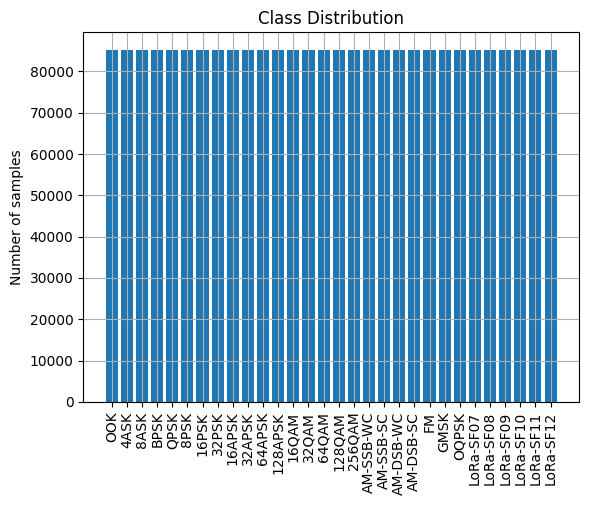

In [64]:
plot_class_distribution(Y=Y_train, class_names=classes)

In [65]:
X_val.shape, Y_val.shape, Z_val.shape

((319488, 1024, 2), (319488, 30), (319488, 1))

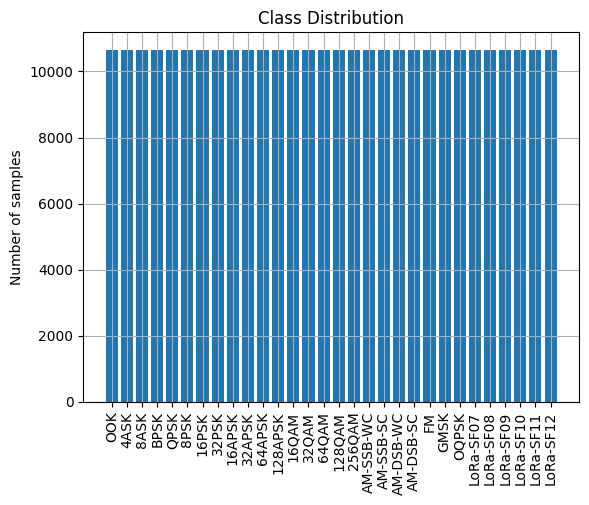

In [66]:
plot_class_distribution(Y=Y_val, class_names=classes)

In [67]:
X_test.shape, Y_test.shape, Z_test.shape

((319488, 1024, 2), (319488, 30), (319488, 1))

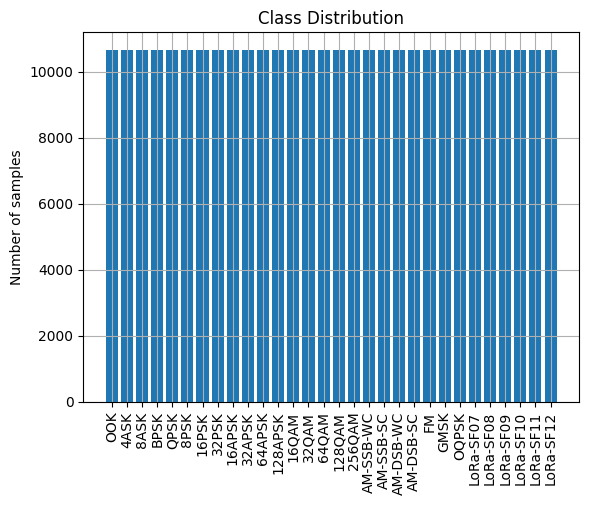

In [68]:
plot_class_distribution(Y=Y_test, class_names=classes)

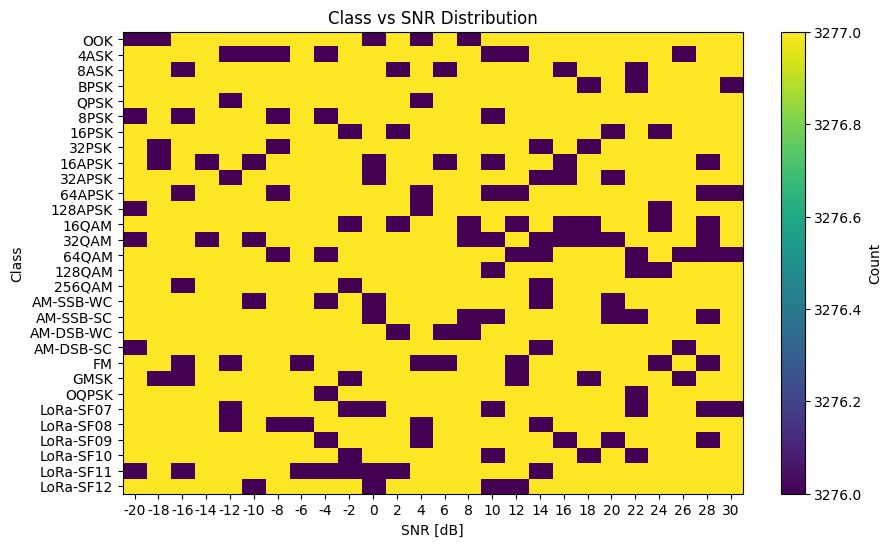

In [69]:
plot_class_snr_heatmap(Y=Y_train, Z=Z_train, class_names=classes)

## SAVE THE COMBINED DATASET

In [70]:
import h5py
import os

def save_dataset(X, Y, Z, path, filename):
    os.makedirs(path, exist_ok=True)
    file_path = os.path.join(path, filename)
    print(f"[INFO] Saving {file_path} ...")

    with h5py.File(file_path, "w") as f:
        f.create_dataset("X", data=X)
        f.create_dataset("Y", data=Y)
        f.create_dataset("Z", data=Z)

    print(f"[INFO] Saved Dataset | X:{X.shape} Y:{Y.shape} Z:{Z.shape} | dtype X:{X.dtype}")

In [71]:
path = "/home/wicom/Descargas/"
save_dataset(X_train, Y_train, Z_train, path = path, filename="RadioML2018_plus_LoRa_train.h5")

[INFO] Saving /home/wicom/Descargas/RadioML2018_plus_LoRa_train.h5 ...
[INFO] Saved Dataset | X:(2555904, 1024, 2) Y:(2555904, 30) Z:(2555904, 1) | dtype X:float32


In [72]:
save_dataset(X_val, Y_val, Z_val, path = path, filename="RadioML2018_plus_LoRa_val.h5")

[INFO] Saving /home/wicom/Descargas/RadioML2018_plus_LoRa_val.h5 ...
[INFO] Saved Dataset | X:(319488, 1024, 2) Y:(319488, 30) Z:(319488, 1) | dtype X:float32


In [73]:
save_dataset(X_test, Y_test, Z_test, path = path, filename="RadioML2018_plus_LoRa_test.h5")

[INFO] Saving /home/wicom/Descargas/RadioML2018_plus_LoRa_test.h5 ...
[INFO] Saved Dataset | X:(319488, 1024, 2) Y:(319488, 30) Z:(319488, 1) | dtype X:float32
